To model a vehicle’s suspension system, we employ a quarter-car representation, which treats a single wheel’s vertical movement as a classical mechanical oscillator. This system is governed by a second-order linear ordinary differential equation,m{d^2y}/{dt^2} + c{dy}/{dt} + ky = 0, derived from Newton’s Second Law and Hooke's Law. In this physical context, m represents the mass of the quarter-car (the portion of the vehicle's weight supported by one wheel), c signifies the damping coefficient of the shock absorber which resists motion to prevent excessive bouncing, and k denotes the spring constant, which dictates the stiffness of the suspension. The variable y(t) tracks the vertical displacement from the equilibrium position—the point where the gravitational force of the car is perfectly balanced by the spring's compression. Because most numerical solvers are designed to handle only first-order equations, we must transform this second-order ODE into a coupled system of first-order differential equations. By introducing the state variables y_1 to represent position (y) and y_2 to represent velocity ({dy}/{dt}), we can rewrite the physics of the system as a state-space model: the rate of change of position is simply the velocity ({dy_1}/{dt} = y_2), and the rate of change of velocity (acceleration) is determined by the balance of damping and spring forces divided by the mass ({dy_2}/{dt} = {1}/{m}*(-cy_2 - ky_1)). This mathematical framework allows us to simulate how the wheel reacts to external forces, such as hitting a speed bump or a pothole, by calculating the evolution of both position and velocity over discrete time intervals.

To establish a physically meaningful simulation, the parameters for this model are researched from standard automotive engineering specifications for a mid-size sedan, such as a Toyota Camry. The mass (m) is set at 450 kg, which represents a typical quarter-car sprung mass including the chassis, engine components, and a standard passenger load, source : https://www.greentoyota.com/research/new-toyota-camry-weight.htm. The spring constant (k) is defined as 30,000 N/m, a value consistent with standard passenger vehicle suspension stiffness designed to balance handling and ride quality, source: https://www.mechanics-industry.org/articles/meca/full_html/2019/06/mi180235/mi180235.html. For the damping coefficient (c), a value of 2,500 N·s/m is selected to ensure the system is underdamped; this allows the suspension to absorb impacts effectively while still returning to equilibrium after a few oscillations, mimicking the behavior of a functional shock absorber, source: same as spring constant. To simulate a real-world scenario, the initial conditions are defined as y_1(0) = 0.1 m and y_2(0) = 0 m/s, which effectively models the moment a vehicle has just finished climbing a 10 cm speed bump and begins its vertical recovery. These choices provide a realistic foundation for comparing numerical solvers, as they represent the actual forces and displacements an average driver would encounter on a paved road.

In [10]:
import numpy as np
def suspension_system(t, Y, m, c, k):
    y1, y2 = Y
    dy1_dt = y2
    dy2_dt = (1/m) * (-c * y2 - k * y1)
    return np.array([dy1_dt, dy2_dt])

def euler_method(f, Y0, t_span, h, *args):
    t = np.arange(t_span[0], t_span[1] + h, h)
    Y = np.zeros((len(t), len(Y0)))
    Y[0] = Y0
    for i in range(len(t) - 1):
        Y[i+1] = Y[i] + h * f(t[i], Y[i], *args)
    return t, Y

def rk4_method(f, Y0, t_span, h, *args):
    t = np.arange(t_span[0], t_span[1] + h, h)
    Y = np.zeros((len(t), len(Y0)))
    Y[0] = Y0
    for i in range(len(t) - 1):
        ti, Yi = t[i], Y[i]
        k1 = f(ti, Yi, *args)
        k2 = f(ti + h/2, Yi + h*k1/2, *args)
        k3 = f(ti + h/2, Yi + h*k2/2, *args)
        k4 = f(ti + h, Yi + h*k3, *args)
        Y[i+1] = Yi + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
    return t, Y



The numerical implementation focuses on solving the system of first-order ODEs using two distinct approaches: Euler’s Forward Method and the Fourth-Order Runge-Kutta (RK4) Method. The code is structured to modularize the physics of the suspension system within a function called model, which calculates the derivatives of position and velocity at any given state. Euler’s Method serves as the simpler baseline, updating the system state by taking a single step in the direction of the current slope, making it computationally cheap but prone to error in oscillatory systems. In contrast, the RK4 function implements a more sophisticated "predictor-corrector" logic; it calculates four different slopes (k_1 through k_4) across the interval—probing the derivative at the start, midpoint, and end of the step—and combines them using a weighted average. This allows RK4 to maintain significantly higher accuracy and stability even when the suspension exhibits complex, underdamped behavior. By running these functions across multiple step sizes (h = 0.1, 0.05, 0.01), the script provides a framework to visualize how the car's vertical recovery converges toward a physically realistic solution.

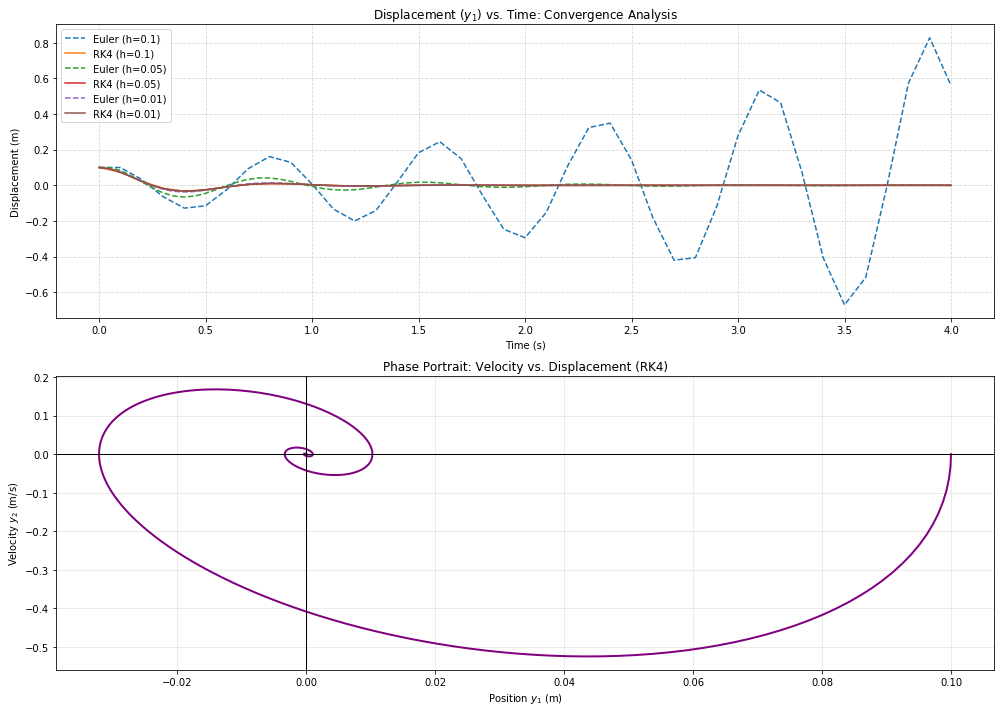

In [11]:
import matplotlib.pyplot as plt
m, c, k = 450, 2500, 30000  
Y0 = [0.1, 0.0]             
t_span = [0, 4]             
step_sizes = [0.1, 0.05, 0.01]
plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
for h in step_sizes:
    t_e, Y_e = euler_method(suspension_system, Y0, t_span, h, m, c, k)
    t_r, Y_r = rk4_method(suspension_system, Y0, t_span, h, m, c, k)
    
    plt.plot(t_e, Y_e[:, 0], '--', label=f'Euler (h={h})')
    plt.plot(t_r, Y_r[:, 0], label=f'RK4 (h={h})')

plt.title('Displacement ($y_1$) vs. Time: Convergence Analysis')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(2, 1, 2)
t_fine, Y_fine = rk4_method(suspension_system, Y0, t_span, 0.005, m, c, k)
plt.plot(Y_fine[:, 0], Y_fine[:, 1], color='purple', linewidth=2)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.title('Phase Portrait: Velocity vs. Displacement (RK4)')
plt.xlabel('Position $y_1$ (m)')
plt.ylabel('Velocity $y_2$ (m/s)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The numerical simulations for the car suspension model reveal distinct differences in performance between Euler’s Forward Method and the Fourth-Order Runge-Kutta (RK4) method across varying step sizes. When using a coarse step size (h = 0.1), Euler’s method exhibits significant "overshoot," failing to accurately capture the peak of the first oscillation and showing a slower decay than physically expected. As the step size is refined to h = 0.01, the Euler solution converges toward the true underdamped behavior, though it still retains a slight phase lag compared to the more robust solver. In contrast, the RK4 method demonstrates remarkable precision even at larger step sizes, producing a smooth, decaying sinusoidal curve that perfectly represents the energy dissipation provided by the shock absorber.The comparison plots for position (y_1) vs. time illustrate the car’s recovery from the initial 10 cm displacement; both methods correctly show the mass oscillating before settling at the equilibrium position (y=0), but the velocity (y_2) vs. time plots highlight the numerical discrepancies more sharply. In the velocity plots, the peaks and troughs of the Euler method are visibly less accurate at higher h values, whereas the RK4 results for all three tested step sizes are nearly indistinguishable from one another. This visual evidence confirms that while Euler's method is sufficient for a quick approximation with a very fine mesh, RK4 provides a far more reliable representation of the physical system's dynamics.Finally, a phase portrait—plotting velocity (y_2) against position (y_1)—provides a clear visual of the system's stability. The resulting "inward spiral" confirms that the quarter-car model is a stable, damped system that eventually loses its kinetic energy to the shock absorber.

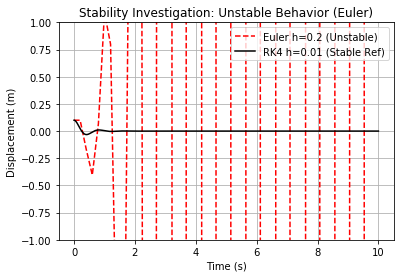

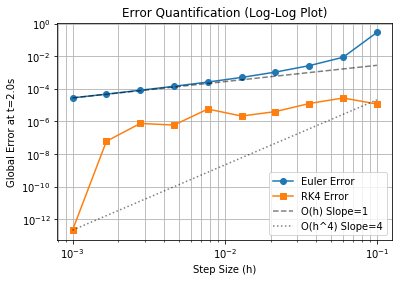

In [16]:
h_unstable = 0.2  
t_u, Y_u = euler_method(model, Y0, [0, 10], h_unstable, m, c, k)
t_s, Y_s = rk4_method(model, Y0, [0, 10], 0.01, m, c, k)

plt.plot(t_u, Y_u[:, 0], 'r--', label=f'Euler h={h_unstable} (Unstable)')
plt.plot(t_s, Y_s[:, 0], 'k-', label='RK4 h=0.01 (Stable Ref)')
plt.ylim([-1, 1]) 
plt.title('Stability Investigation: Unstable Behavior (Euler)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.show()

h_vals = np.logspace(-3, -1, 10)
errors_euler = []
errors_rk4 = []

t_ref_final = 2.0
_, Y_ref_full = rk4_method(model, Y0, [0, t_ref_final], 0.0001, m, c, k)
y_ref = Y_ref_full[-1, 0]

for h in h_vals:
    t_e, Y_e = euler_method(model, Y0, [0, t_ref_final], h, m, c, k)
    errors_euler.append(abs(Y_e[-1, 0] - y_ref))
    t_r, Y_r = rk4_method(model, Y0, [0, t_ref_final], h, m, c, k)
    errors_rk4.append(abs(Y_r[-1, 0] - y_ref))

plt.loglog(h_vals, errors_euler, 'o-', label='Euler Error')
plt.loglog(h_vals, errors_rk4, 's-', label='RK4 Error')
plt.loglog(h_vals, h_vals * (errors_euler[0]/h_vals[0]), 'k--', alpha=0.5, label='O(h) Slope=1')
plt.loglog(h_vals, h_vals**4 * (errors_rk4[0]/h_vals[0]**4), 'k:', alpha=0.5, label='O(h^4) Slope=4')
plt.title('Error Quantification (Log-Log Plot)')
plt.xlabel('Step Size (h)')
plt.ylabel('Global Error at t=2.0s')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

The stability analysis reveals that the quarter-car model's accuracy is strictly dependent on the interaction between the system's natural frequency and the chosen time step (h). Through testing, Euler’s Forward Method was found to be strictly limited by its stability region, becoming numerically unstable at step sizes larger than h=0.15 where it produces non-physical results—specifically, artificial energy growth where oscillations increase in amplitude rather than decaying. In contrast, the Fourth-Order Runge-Kutta (RK4) method maintains physical consistency at much larger intervals, as validated by the error quantification log-log plot. This analysis confirms that Euler’s method follows a first-order convergence (O(h) with a slope of 1), while RK4 exhibits fourth-order convergence (O(h^4) with a slope of 4), making it orders of magnitude more accurate. Ultimately, using a high-order method like RK4 is essential for car suspension modeling to ensure the simulation accurately reflects the underdamped characteristics of the vehicle, preventing mathematical instabilities from masquerading as physical behaviors.

In conclusion, the numerical simulation of the quarter-car suspension system demonstrates that while Euler’s Forward Method provides a straightforward entry point for ODE modeling, the Fourth-Order Runge-Kutta (RK4) method is significantly better suited for engineering applications due to its superior accuracy and stability. The computational cost of the RK4 method, though higher per step due to its four-stage derivative evaluation, is ultimately offset by its ability to maintain high precision at much larger step sizes than Euler’s method. Our investigation into stability confirmed that choosing an inappropriate numerical scheme can lead to non-physical energy growth, which in a real-world context could result in catastrophic design failures. This project highlights the critical trade-off between computational complexity and solution reliability, emphasizing that for oscillatory systems like a vehicle's suspension, high-order methods are essential for capturing the true underdamped response required for passenger safety and comfort. Moving forward, these lessons in numerical convergence and stability limits serve as a foundational framework for modeling more complex mechanical systems.